# Term-structure model examples

There are many different term-structure models. These can be fitted to the bootstrapped yields (see the examples in notebook `04_bootstrap.ipynb`) to form a full term-structure of interest rates. The term-structure models inherit of the `TermStructureABC` abstract base class. 

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantpy.math.curve import NelsonSiegel
from quantpy.math.curve import Svensson
from quantpy.math.curve import MultidynamicModel

plt.style.use('seaborn-v0_8')
example_root = Path(os.path.abspath(""))

In [2]:
yield_df = pd.read_csv(example_root / "data" / "fi_yields_2026-02-02.csv")
yield_df.head(5)

,TimeToMaturity,ZeroYield
0,0.200000,0.019236
1,0.625000,0.019316
2,1.213889,0.019849
3,1.638889,0.020494
4,2.452778,0.020869


In [3]:
maturities = yield_df["TimeToMaturity"].to_numpy()
yields     = yield_df["ZeroYield"].to_numpy()

## Nelson-Siegel model

The Nelson-Siegel model is implemented in the `NelsonSiegel` class

In [4]:
model = NelsonSiegel(yields, maturities)

/home/kasper/GIT/quantpy/quantpy/math/curve/NelsonSiegel.py:18: RuntimeWarning: invalid value encountered in divide
  return beta_0 + beta_1 * (1. - np.exp(-maturities / tau)) / (maturities / tau) \
/home/kasper/GIT/quantpy/quantpy/math/curve/NelsonSiegel.py:19: RuntimeWarning: invalid value encountered in divide
  + beta_2 * ((1. - np.exp(-maturities / tau)) / (maturities / tau) - np.exp(-maturities / tau))


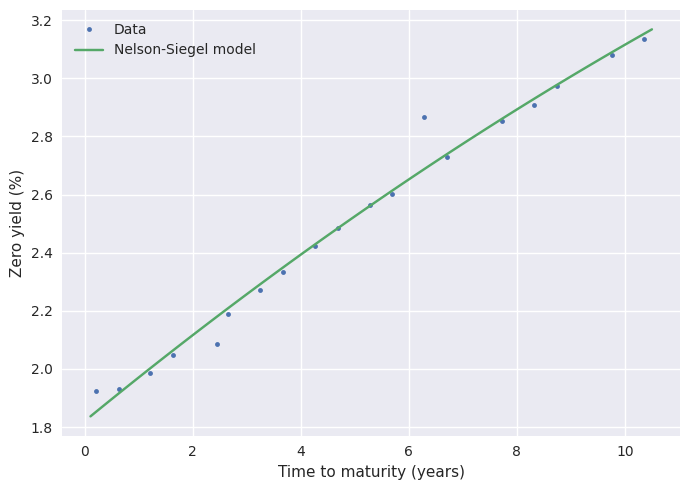

In [5]:
tt = np.linspace(0, 10.5, 100)

fig = plt.figure(figsize=(7, 5))

plt.plot(maturities, yields * 100, '.', label="Data")
plt.plot(tt, model(tt) * 100, label="Nelson-Siegel model")
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

plt.legend()
fig.tight_layout()

plt.show()

## Svensson model

The Svensson model is implemented in the `Svensson` class

In [6]:
model = Svensson(yields, maturities)

/home/kasper/GIT/quantpy/quantpy/math/curve/Svensson.py:19: RuntimeWarning: invalid value encountered in divide
  return beta_0 + beta_1 * (1. - np.exp(-maturities / tau_1)) / (maturities / tau_1) \
/home/kasper/GIT/quantpy/quantpy/math/curve/Svensson.py:20: RuntimeWarning: invalid value encountered in divide
  + beta_2 * ((1. - np.exp(-maturities / tau_1)) / (maturities / tau_1) - np.exp(-maturities / tau_1)) \
/home/kasper/GIT/quantpy/quantpy/math/curve/Svensson.py:21: RuntimeWarning: invalid value encountered in divide
  + beta_3 * ((1. - np.exp(-maturities / tau_2)) / (maturities / tau_2) - np.exp(-maturities / tau_2))


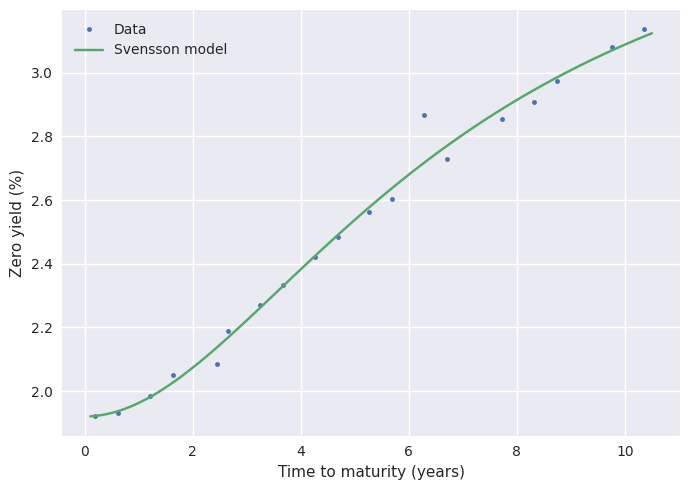

In [7]:
tt = np.linspace(0, 10.5, 100)

fig = plt.figure(figsize=(7, 5))

plt.plot(maturities, yields * 100, '.', label="Data")
plt.plot(tt, model(tt) * 100, label="Svensson model")
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

plt.legend()
fig.tight_layout()

plt.show()

## Multidynamic model

The new proposed term-structure model is implemented in the `MultidynamicModel` class. In order to benefit from the form the proposed model, extend the curve points to full(er) yield structure.

In [8]:
maturities = np.array(yield_df["TimeToMaturity"].to_list() + [12, 14, 16 ,18, 20])
yields     = np.array(yield_df["ZeroYield"].to_list() + [0.032, 0.0325, 0.032, 0.031, 0.030])

In [9]:
model = MultidynamicModel(yields, maturities, method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=10_000)

[ 2.09625636e+00  2.41325246e-02  3.37983737e-03 -3.07421787e-02
  1.29312517e-02  6.55145662e-05]


/home/kasper/GIT/quantpy/quantpy/math/curve/MultidynamicModel.py:19: RuntimeWarning: divide by zero encountered in divide
  return beta_0 + beta_1 / 2. * maturities + tau / maturities * (beta_2 + beta_3) * (1. - np.exp(-maturities / tau)) \
/home/kasper/GIT/quantpy/quantpy/math/curve/MultidynamicModel.py:19: RuntimeWarning: invalid value encountered in multiply
  return beta_0 + beta_1 / 2. * maturities + tau / maturities * (beta_2 + beta_3) * (1. - np.exp(-maturities / tau)) \


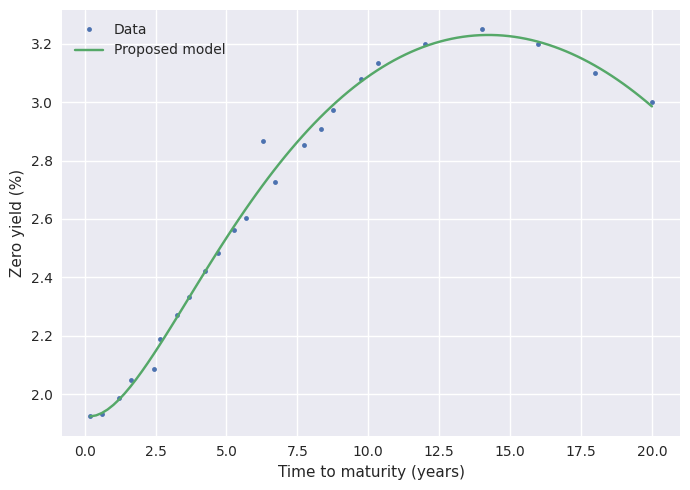

In [10]:
tt = np.linspace(0, 20, 100)

fig = plt.figure(figsize=(7, 5))

plt.plot(maturities, yields * 100, '.', label="Data")
plt.plot(tt, model(tt) * 100, label="Proposed model")
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

plt.legend()
fig.tight_layout()

plt.show()